# Lab 1 · EDA and simple baselines
### By Vicente Rodríguez and Baptiste Vial.

---

Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [1]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__)

DATA MODE: snapshot | Python: 3.13.5 | pandas: 2.2.3


---

## 1. Target and audit
State the prediction moment, unit, population and target. Distinguish final classification from completing a race. Explain the source limitations.

### Prediction moment

We predict **after qualifying has finished and before the Grand Prix starts**. The only predictor is `qualifying_position` from the **qualifying table**. We do not use `grid` from the results table: it is published together with the race result, it already includes post-qualifying grid penalties and pit-lane starts (`grid = 0`), and the brief fixes qualifying position as the pre-race information. Position, points, status and laps are post-race information: we use them only to audit and explore the training data, never as predictors.

### Unit

One observation is **one driver in one Grand Prix**, identified by the key `(season, round, driver_id)`.

### Population

The population is **every driver/race record in the supplied race-results snapshots**. For training that means all drivers in 2019–2021 (1,200 rows), not a single driver. We keep every row: retirements, non-finishers, withdrawn and disqualified entries, and entries with a missing qualifying record. This is a *retrospective* population built from who appears in the results table. It is not the entry list that was known before each race.

### Target

`target_top10 = 1` when the source's numeric final race position is 1–10, and `0` otherwise. This is **final classification**, which is not the same as:
- **completing the race**: a driver can retire and still be classified by the laps they completed, and a driver who finishes 11th or lower is a 0;
- **scoring points**: points also depend on scoring rules such as the fastest-lap bonus, half points and later penalties;
- winning, or a constructor result.

### Data limitations

The snapshot reflects results as they are recorded *today*, so it can include corrections made after a race (for example a post-race time penalty or a disqualification that moved a driver out of the top ten). It is therefore not an exact reconstruction of what was known at the historical prediction moment. The population is also retrospective: drivers who were entered but never appear in the results table are invisible to us. Finally, a few results rows have no qualifying record, so the qualifying rule has to fall back to the training majority for them.

In [2]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

### Data integrity checks

We audit the **full training population** (all drivers, 2019–2021) and cover: keys, duplicates, unmatched records in both directions, missingness, coverage by season, final classification vs completing the race, and qualifying position vs grid.

In [3]:
# Audit of the full training population (all drivers, 2019-2021).
KEYS = ['season', 'round', 'driver_id']

# 1. Keys: nulls and duplicates in each source and in the merged table
key_check = pd.DataFrame({
    name: {'rows': len(df),
           'null_keys': int(df[KEYS].isna().any(axis=1).sum()),
           'duplicate_keys': int(df.duplicated(KEYS).sum())}
    for name, df in [('qualifying', q_train), ('results', r_train), ('merged', train)]
}).T
print('================================================================================')
print('Key audit: rows, null keys, duplicate keys')
display(key_check)


# 2. Unmatched records in both directions.
# A left join from results only shows results without qualifying (left_only). Qualifying rows with no
# race result can never appear in it, so we check them with an anti-join from the qualifying side.
q_side = q_train[KEYS].merge(r_train[KEYS], on=KEYS, how='left', indicator=True)
print('================================================================================')
print('Unmatched records:')
print('Results rows without a qualifying record (left_only):', int(train['qualifying_match'].eq('left_only').sum()))
print('Qualifying rows without a race result (qualifying-only):', int(q_side['_merge'].eq('left_only').sum()))

# 3. Missingness per column, and the rows that will need the missing-qualifying fallback
missing = train.isna().sum()
print('================================================================================')
print('Missing values per column:')
display(missing[missing > 0].rename('missing_rows').to_frame())
print('=================================================================================')
print('Rows with missing qualifying position (will need fallback):', int(train['qualifying_position'].isna().sum()))
display(train.loc[train['qualifying_position'].isna(),
                  ['season', 'round', 'race_name', 'driver_id', 'constructor_id', 'grid', 'position', 'status']])

# 4. Coverage by season
coverage = train.groupby('season').agg(
    races=('round', 'nunique'),
    drivers=('driver_id', 'nunique'),
    rows=('driver_id', 'size'),
    missing_qualifying=('qualifying_position', lambda x: int(x.isna().sum())),
    target_rate=('target_top10', 'mean'),
)
coverage['rows_per_race'] = coverage['rows'] / coverage['races']
print('=================================================================================')
print('Coverage by season:')
display(coverage.round(3))

# 5. Final classification vs completing the race (status is post-race: audit only, not a predictor)
completed = train['status'].eq('Finished') | train['status'].str.match(r'^\+\d+ Laps?$')
print('=================================================================================')
print('Rows with status indicating the driver completed the race:', int(completed.sum()), 'of', len(completed))
display(pd.crosstab(train['target_top10'], completed.map({True: 'completed race', False: 'did not complete'}),
                    margins=True))
print('=================================================================================')
print('Rows with non-numeric position_text (DNF, DNS, DSQ, etc.):', int(train['position_text'].str.isdigit().eq(False).sum()), 'of', len(train))
display(train['position_text'].astype(str).value_counts()
        .loc[lambda s: ~s.index.str.isdigit()].rename('rows').to_frame())
print('=================================================================================')
print('Rows with points > 0:', int(train['points'].gt(0).sum()), 'of', len(train))
display(pd.crosstab(train['target_top10'], train['points'].gt(0).map({True: 'points > 0', False: 'no points'})))


# 6. Qualifying position vs results grid (why grid is not our predictor)
has_q = train['qualifying_position'].notna()
print('=================================================================================')
print('Rows where grid differs from qualifying position:',
      int((train.loc[has_q, 'grid'] != train.loc[has_q, 'qualifying_position']).sum()), 'of', int(has_q.sum()))
print('Rows with grid = 0 (pit-lane start):', int(train['grid'].eq(0).sum()))

Key audit: rows, null keys, duplicate keys


,rows,null_keys,duplicate_keys
qualifying,1197,0,0
results,1200,0,0
merged,1200,0,0


Unmatched records:
Results rows without a qualifying record (left_only): 3
Qualifying rows without a race result (qualifying-only): 0
Missing values per column:


,missing_rows
qualifying_position,3


Rows with missing qualifying position (will need fallback): 3


...

Rows with non-numeric position_text (DNF, DNS, DSQ, etc.): 155 of 1200


,rows
position_text,
R,146
W,6
D,3


Rows with points > 0: 600 of 1200


points,no points,points > 0
target_top10,,
0,600,0
1,0,600


Rows where grid differs from qualifying position: 381 of 1197
Rows with grid = 0 (pit-lane start): 29


### Audit findings

- **Rows and keys:** qualifying has 418 / 340 / 439 rows and results 420 / 340 / 440 rows for 2019 / 2020 / 2021. No source has null or duplicate `(season, round, driver_id)` keys, and the merged table keeps exactly the 1,200 results rows (`assert len(train)==len(r_train)` passes).
- **Unmatched records:** 1,197 rows match (`both`). **3 results rows have no qualifying record** (`left_only`): two in the 2019 Chinese GP and one in the 2021 Monaco GP. **No qualifying row lacks a race result**, so no qualifying-only record exists in train.
- **Missingness:** `qualifying_position` is missing only for those 3 rows (2 in 2019, 1 in 2021). They stay in the population and will use the training-majority fallback in the qualifying baseline. One of them (2019 Chinese GP, pit-lane start, final position 10) is a target-1 row, so the fallback of 0 would produce a false negative on it.
- **Coverage:** 21 / 17 / 22 races, with exactly 20 rows per race in every season. 2020 is shorter (COVID calendar) and has 23 different drivers because of substitutes. The training target rate is **exactly 0.500** (600 of 1,200) because each race has 10 classified top-ten places out of 20 rows. The majority is therefore an exact tie, which the fixed rule resolves to **0**.
- **Classification vs completing the race:** 176 rows did not complete the race (146 `R`, 6 `W`, 3 `D`, plus other non-finishing statuses). In 2019–2021 none of them was classified in the top ten, but they are still kept as target-0 rows. 424 drivers completed the race and still got a 0. In this period `points > 0` coincides with `target_top10` for all 1,200 rows. That is an observed fact for these seasons, not the definition we use.
- **Grid vs qualifying:** grid differs from qualifying position in 381 of the 1,197 rows that have qualifying (about 32%), and 29 rows have `grid = 0`. This confirms that `grid` carries post-qualifying information and must not replace the qualifying table.

**Decision:** keep all 1,200 rows, predict only from `qualifying_position`, and report the 3 fallback rows explicitly.

### Why the left join instead of the inner join?

The evaluated population is defined by the **results** table: every driver/race record that has a final classification. We therefore start from results and left-join qualifying on `(season, round, driver_id)`. An inner join would silently drop every results row without a qualifying record. In train that removes the 3 `left_only` rows (2019 Chinese GP ×2, 2021 Monaco GP ×1) and shrinks the population from 1,200 to 1,197. Those rows are not random: they are exactly the cases where the qualifying rule cannot be applied. Dropping them would hide the fallback, make the qualifying baseline look like it covers every row, and evaluate the two baselines on a smaller, filtered population instead of the one defined in the brief. The left join keeps them with a null `qualifying_position`, so the missing-qualifying policy stays visible and can be counted in calibration and test.

---

## 2. EDA question 1
**Question:** How likely is a driver to finish in the top 10, depending on whether they qualified in the top 10 or not?

Train data only (2019–2021). We cross the qualifying top-10 flag (the pre-race information our baseline uses) with the race top-10 target and turn the four combinations into likelihoods within each qualifying group. Rows with a missing qualifying position cannot be placed in either group, so they are reported separately instead of being dropped silently. As a check against the accumulation trap, we also recompute the rates per season to see whether pooling three seasons hides differences.

race_group,Race top 10,Race outside top 10,total
quali_group,,,
Qualified top 10,445,155,600
Qualified 11th or lower,154,443,597


race_group,Race top 10 (%),Race outside top 10 (%)
quali_group,,
Qualified top 10,74.2,25.8
Qualified 11th or lower,25.8,74.2


Rows excluded because qualifying is missing: 3 | their target values: [1, 0, 0]


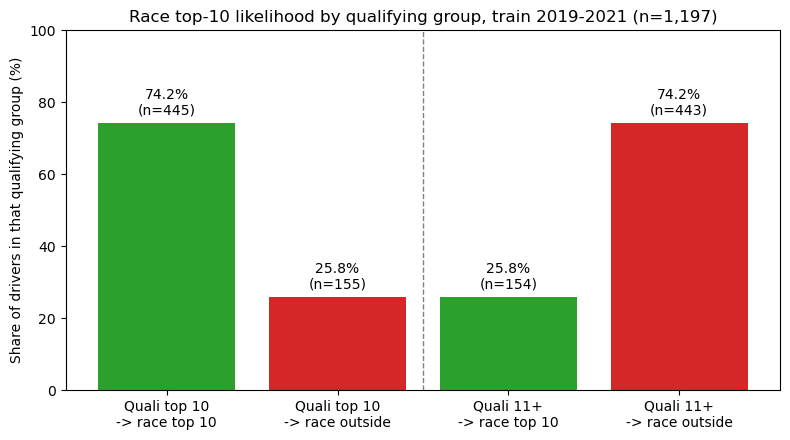

race_top10_rate                                     rows  \
quali_group Qualified 11th or lower Qualified top 10 Qualified 11th or lower   
season                                                                         
2019                          0.274            0.724                     208   
2020                          0.259            0.741                     170   
2021                          0.242            0.759                     219   

                              
quali_group Qualified top 10  
season                        
2019                     210  
2020                     170  
2021                     220

In [4]:
# EDA question 1 (train only): qualifying top 10 vs race top 10
has_q = train['qualifying_position'].notna()
eda1 = train.loc[has_q].copy()
eda1['quali_group'] = np.where(eda1['qualifying_position'].le(10), 'Qualified top 10', 'Qualified 11th or lower')
eda1['race_group'] = np.where(eda1['target_top10'].eq(1), 'Race top 10', 'Race outside top 10')

# Counts and likelihood within each qualifying group (each row of the table sums to 100%)
order_q = ['Qualified top 10', 'Qualified 11th or lower']
order_r = ['Race top 10', 'Race outside top 10']
counts = pd.crosstab(eda1['quali_group'], eda1['race_group']).loc[order_q, order_r]
rates = pd.crosstab(eda1['quali_group'], eda1['race_group'], normalize='index').loc[order_q, order_r]
display(counts.assign(total=counts.sum(axis=1)))
display((rates * 100).round(1).add_suffix(' (%)'))
print('Rows excluded because qualifying is missing:', int((~has_q).sum()),
      '| their target values:', train.loc[~has_q, 'target_top10'].tolist())

# Four bars: how likely each race outcome is, given the qualifying group
labels = ['Quali top 10\n-> race top 10', 'Quali top 10\n-> race outside',
          'Quali 11+\n-> race top 10', 'Quali 11+\n-> race outside']
values = [rates.loc[q, r] * 100 for q in order_q for r in order_r]
ns = [counts.loc[q, r] for q in order_q for r in order_r]
colors = ['tab:green', 'tab:red', 'tab:green', 'tab:red']

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, values, color=colors)
for bar, v, n in zip(bars, values, ns):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f'{v:.1f}%\n(n={n})', ha='center', va='bottom')
ax.axvline(1.5, color='grey', linestyle='--', linewidth=1)
ax.set_ylim(0, 100)  # full 0-100% scale so the bar heights are not exaggerated
ax.set_ylabel('Share of drivers in that qualifying group (%)')
ax.set_title('Race top-10 likelihood by qualifying group, train 2019-2021 (n=1,197)')
plt.tight_layout()
plt.show()

# Accumulation check: does pooling 2019-2021 hide season-level differences?
by_season = (eda1.groupby(['season', 'quali_group'])['target_top10']
             .agg(race_top10_rate='mean', rows='size')
             .unstack('quali_group'))
display(by_season.round(3))

**Answer (observed values).** Of the 600 drivers who qualified in the top 10, **445 (74.2%)** also finished in the top 10 and 155 (25.8%) did not. Of the 597 who qualified 11th or lower, only **154 (25.8%)** finished in the top 10 and 443 (74.2%) did not. So qualifying in the top 10 roughly triples the likelihood of a top-10 finish (74.2% vs 25.8%). The two error groups are almost equal (155 vs 154) because every race has exactly 10 top-10 places: each driver who drops out of the top 10 frees a place for someone who qualified lower.

**Trap check (accumulation/pooling).** The pooled rates are not driven by one season. The top-10 qualifiers' rate is 72.4% / 74.1% / 75.9% and the rest's rate is 27.4% / 25.9% / 24.2% for 2019 / 2020 / 2021. The plot uses a full 0–100% axis and shows n on every bar, so the gap is not exaggerated by the framing.

**Consequence for the prediction.** Qualifying position is a strong but imperfect pre-race signal. If the qualifying top-10 rule were applied to these training rows, it would be wrong about one time in four in *both* directions: about 155 false positives and 154 false negatives out of 1,197, which is about 74% accuracy. This supports using the fixed qualifying baseline as the main comparison against the majority rule, which gets 50% here because the target rate is exactly 0.5. **Limitations:** this is a description of the training years, not a guarantee for 2022–2024, and it shows association only. It also doesn't tell us *where* the errors happen, for example whether they cluster around P9–P12 near the cutoff. The 3 rows with missing qualifying (targets 1, 0, 0) are outside this table and will use the majority fallback (0).

---

## 3. EDA question 2
**Question:** When both drivers of a constructor qualify in the top 10, how often do both finish in the top 10? Does treating teammates as independent observations distort what we expect from the errors?

**Design (train only, 2019–2021):** we group rows by `(season, round, constructor_id)` and keep the pairs where both cars have `qualifying_position` ≤ 10 (the 3 rows with missing qualifying never count). For each pair we count how many cars finished top 10: both, exactly one, or neither. We compare these counts with what we would expect if teammates were independent and shared the same conversion rate *p*: P(both) = *p*², P(exactly one) = 2*p*(1−*p*), P(neither) = (1−*p*)². `target_top10` is only used here for exploration.

**Friday trap checked (independence fallacy):** the unit is "one driver in one race", so it is tempting to treat every row as an independent trial. Teammates share a car, power unit, pit crew and strategy, so their errors may come together.

Constructor-race pairs: 600 | pairs with both cars qualified P1-P10: 226
Top-10 conversion rate of these cars: p = 0.777


,observed,observed_%,expected_if_independent
outcome,,,
both,142,62.8,136.3
exactly one,67,29.6,78.4
neither,17,7.5,11.3


,pairs,both_rate,neither
constructor_id,,,
mercedes,60,0.78,1
red_bull,46,0.63,4
mclaren,35,0.57,3
ferrari,34,0.74,2
renault,15,0.47,1
alphatauri,12,0.08,1
racing_point,9,0.78,0
alpine,5,0.60,0
haas,5,0.20,3


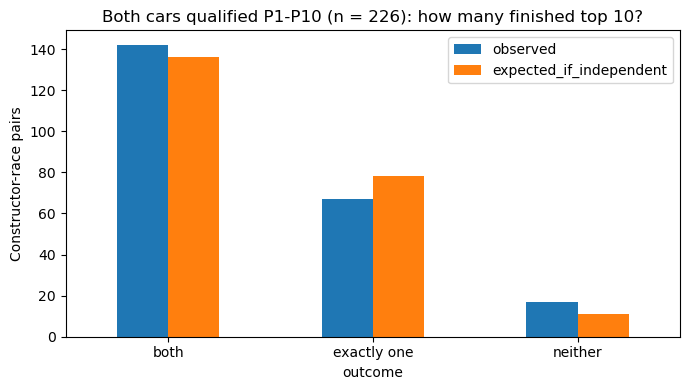

In [5]:
# EDA question 2: pairs where both teammates qualified P1-P10. Train only (2019-2021).
PAIR = ['season', 'round', 'constructor_id']
t = train.copy()
t['q10'] = t['qualifying_position'].le(10)   # missing qualifying (NaN) never counts as Q10

pairs = t.groupby(PAIR).agg(n_q10=('q10', 'sum'), n_top10=('target_top10', 'sum')).reset_index()
both_q = pairs[pairs['n_q10'] == 2].copy()
both_q['outcome'] = both_q['n_top10'].map({2: 'both', 1: 'exactly one', 0: 'neither'})
n = len(both_q)
print('Constructor-race pairs:', len(pairs), '| pairs with both cars qualified P1-P10:', n)

# If teammates were independent with the same conversion rate p:
# P(both) = p^2, P(exactly one) = 2p(1-p), P(neither) = (1-p)^2
p = both_q['n_top10'].sum() / (2 * n)
order = ['both', 'exactly one', 'neither']
table = pd.DataFrame({'observed': both_q['outcome'].value_counts().reindex(order, fill_value=0)})
table['observed_%'] = 100 * table['observed'] / n
table['expected_if_independent'] = n * np.array([p**2, 2 * p * (1 - p), (1 - p)**2])
print(f'Top-10 conversion rate of these cars: p = {p:.3f}')
display(table.round(1))

# Conversion is not the same for every team
by_team = (both_q.groupby('constructor_id')['outcome']
           .agg(pairs='size', both_rate=lambda s: s.eq('both').mean(), neither=lambda s: int(s.eq('neither').sum()))
           .sort_values('pairs', ascending=False))
display(by_team.round(2))

ax = table[['observed', 'expected_if_independent']].plot.bar(rot=0, figsize=(7, 4))
ax.set_ylabel('Constructor-race pairs')
ax.set_title(f'Both cars qualified P1-P10 (n = {n}): how many finished top 10?')
plt.tight_layout(); plt.show()

### Findings, Friday trap and decision

- **Frequency:** 226 of the 600 constructor-race pairs had both cars qualify P1–P10. Both cars finished top 10 in **142 pairs (62.8%)**, exactly one in **67 (29.6%)** and neither in **17 (7.5%)**.
- **Independence check (p = 0.777):** if teammates were independent we would expect 136.3 / 78.4 / 11.3 pairs. We observe more "neither" pairs (17 vs 11.3, about 1.5×) and fewer "exactly one" pairs (67 vs 78.4). Teammates tend to succeed or fail together more than independence predicts.
- **Team strength matters:** the conversion rate is not the same for every team. Both cars finished top 10 in 78% of Mercedes pairs (60 pairs) but only 8% of AlphaTauri pairs (12) and 20% of Haas pairs (5, with 3 "neither"). Part of the excess "neither" pairs comes from mixing strong and weak teams, not only from shared race-day problems.
- **Consequence for the "Qualifying top ten" baseline:** it predicts 1 for both cars in all 226 pairs, i.e. a double top-10 100% of the time vs 62.8% observed. Its false positives here are 67 + 2×17 = 101, and 34 of them come from the 17 pairs where both cars failed together.

**Decision / limitation:** we keep the driver-race unit and the baseline unchanged (the predictor is fixed). When reading calibration errors, we will not treat each false positive as an independent error: some come in teammate pairs from the same team and race. Limitation: only 226 pairs and 17 "neither" events, so the evidence is small, and we do not separate team-strength effects from true shared shocks.

---

## 4. EDA question 3
**Question:** How many of the qualifying rule's errors come from drivers who did not complete the race, and how would our conclusions change if we only analysed drivers who completed it?

Train data only (2019–2021), with the 1,197 rows that have a qualifying position. A driver *completed the race* when `status` is `Finished` or `+n Lap(s)`. Everything else (accidents, mechanical failures, withdrawals, disqualifications) counts as not completed. `status` is post-race information, so we use it here only for exploration, never as a predictor.

**Friday trap checked (selection):** a tempting "clean-up" is to analyse only drivers who reached the flag, because retirements look like noise. We compare the full population with that filtered subset to show what the filter would hide.

target_top10                                0    1   All
quali_group             completed                       
Qualified 11th or lower completed         341  154   495
                        did not complete  102    0   102
Qualified top 10        completed          81  445   526
                        did not complete   74    0    74
All                                       598  599  1197

Non-completion rate by season: {2019: 0.144, 2020: 0.168, 2021: 0.134}


,All rows (our population),Completed only (filtered)
rows,1200.000,1024.000
target_rate,0.500,0.586
implied_majority,0.000,1.000
top10_rate_if_quali_top10,0.742,0.846
top10_rate_if_quali_11plus,0.258,0.311
quali_rule_accuracy,0.742,0.770
quali_rule_FP,155.000,81.000
quali_rule_FN,154.000,154.000


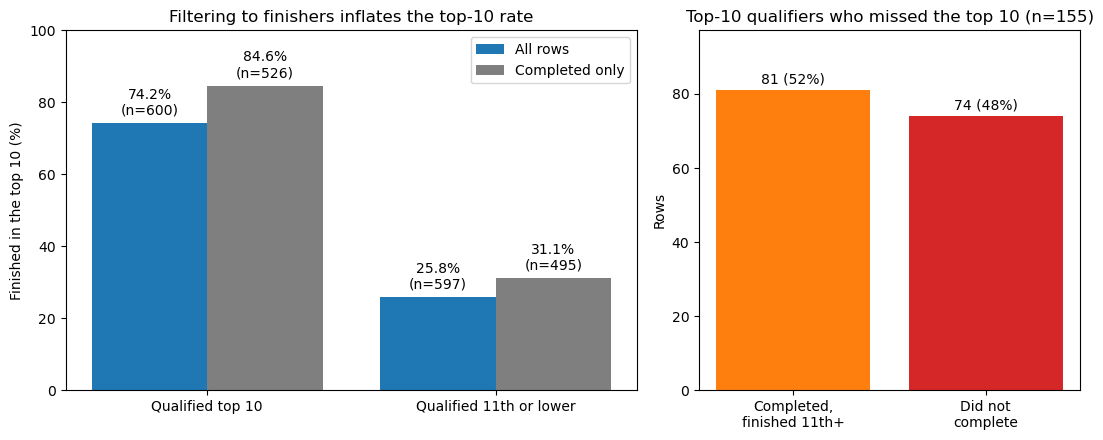

In [6]:
# EDA question 3 (train only): non-finishers and the selection trap.
# status is post-race: used for exploration only, never as a predictor.
all3 = train.copy()  # all 1,200 rows: needed for the target rate and the majority
all3['completed'] = all3['status'].eq('Finished') | all3['status'].str.match(r'^\+\d+ Laps?$')
eda3 = all3.loc[all3['qualifying_position'].notna()].copy()  # 1,197 rows where the qualifying rule applies
eda3['quali_group'] = np.where(eda3['qualifying_position'].le(10), 'Qualified top 10', 'Qualified 11th or lower')

# Where do the outcomes come from? (qualifying group x completed race x target)
display(pd.crosstab([eda3['quali_group'], eda3['completed'].map({True: 'completed', False: 'did not complete'})],
                    eda3['target_top10'], margins=True))
print('Non-completion rate by season:', eda3.groupby('season')['completed'].apply(lambda x: round(1 - x.mean(), 3)).to_dict())

# Selection check: the same summaries on the full population vs "completed only"
def summary(frame):
    # Target rate and majority on every row; qualifying-rule figures on rows with a qualifying position
    rule_rows = frame[frame['qualifying_position'].notna()]
    pred, y = rule_rows['qualifying_position'].le(10).astype(int), rule_rows['target_top10']
    return pd.Series({
        'rows': len(frame),
        'target_rate': frame['target_top10'].mean(),
        'implied_majority': int(frame['target_top10'].mean() > 0.5),  # same tie rule as the fixed baseline
        'top10_rate_if_quali_top10': y[pred == 1].mean(),
        'top10_rate_if_quali_11plus': y[pred == 0].mean(),
        'quali_rule_accuracy': (pred == y).mean(),
        'quali_rule_FP': int(((pred == 1) & (y == 0)).sum()),
        'quali_rule_FN': int(((pred == 0) & (y == 1)).sum()),
    })

selection = pd.DataFrame({'All rows (our population)': summary(all3),
                          'Completed only (filtered)': summary(all3[all3['completed']])})
display(selection.round(3))

# Left: top-10 likelihood per qualifying group, with and without the filter.
# Right: what the qualifying rule's false positives are made of.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [3, 2]})
groups = ['Qualified top 10', 'Qualified 11th or lower']
x = np.arange(len(groups))
for offset, (label, frame, color) in zip([-0.2, 0.2], [('All rows', eda3, 'tab:blue'),
                                                     ('Completed only', eda3[eda3['completed']], 'tab:grey')]):
    rates = frame.groupby('quali_group')['target_top10'].mean().loc[groups] * 100
    ns = frame['quali_group'].value_counts().loc[groups]
    bars = ax1.bar(x + offset, rates, width=0.4, label=label, color=color)
    for bar, v, n in zip(bars, rates, ns):
        ax1.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f'{v:.1f}%\n(n={n})', ha='center', va='bottom')
ax1.set_xticks(x, groups)
ax1.set_ylim(0, 100)
ax1.set_ylabel('Finished in the top 10 (%)')
ax1.set_title('Filtering to finishers inflates the top-10 rate')
ax1.legend(loc='upper right')

fp = eda3[eda3['quali_group'].eq('Qualified top 10') & eda3['target_top10'].eq(0)]
fp_parts = fp['completed'].map({True: 'Completed,\nfinished 11th+', False: 'Did not\ncomplete'}).value_counts()
bars = ax2.bar(fp_parts.index, fp_parts.values, color=['tab:orange', 'tab:red'][:len(fp_parts)])
for bar, v in zip(bars, fp_parts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 1, f'{v} ({v / len(fp):.0%})', ha='center', va='bottom')
ax2.set_ylim(0, fp_parts.max() * 1.2)
ax2.set_ylabel('Rows')
ax2.set_title(f'Top-10 qualifiers who missed the top 10 (n={len(fp)})')
plt.tight_layout()
plt.show()

**Answer (observed values).** 176 of the 1,197 rows (14.7%) did not complete the race. The yearly rate is 14.4% / 16.8% / 13.4% for 2019 / 2020 / 2021, so this isn't a one-season effect. None of them was classified in the top 10. Among the 600 top-10 qualifiers, the rule's 155 false positives split into **74 (48%) who did not complete the race** and 81 (52%) who finished but 11th or lower. So almost half of the qualifying rule's false positives come from retirements and other non-finishes, which qualifying position cannot anticipate.

**Trap check (selection).** If we kept only the rows that completed the race (1,024 of 1,200):
- the top-10 rate of top-10 qualifiers would rise from **74.2% to 84.6%**, and for the rest from 25.8% to 31.1%;
- the qualifying rule's accuracy would rise from 74.2% to 77.0%, and its false positives would fall from 155 to 81;
- the overall target rate would move from **0.500 to 0.586**, which **flips the training majority from 0 to 1**.

Note: the target rate and majority are computed on all 1,200 rows, as in the fixed baseline. On only the 1,197 rows with a qualifying position the rate is 599/1,197 = 0.5004, which would already break the exact tie.

The filter therefore flatters the qualifying baseline and changes the other baseline itself. It is also impossible at prediction time: we can't know before the race who will finish, because completion is only known afterwards.

**Consequence for the prediction.** We keep every row, including the 176 non-finishers, as the brief requires. We read the qualifying rule's ~26% false-positive rate as partly irreducible with pre-race information. **Limitations:**
- The completed/not-completed split relies on the source's `status` text: `+n Laps` counts as completed, while withdrawn (`W`) and disqualified (`D`) entries count as not completed.
- Non-finishing rates may differ in 2022–2024 (new car regulations from 2022), so the share of errors caused by retirements may not transfer to calibration or test.

---

## 5. Baselines and 2022 check

### The two fixed rules

Both rules are fixed in advance. There is no model training or tuning: the only value learned from data is the training majority, and it comes from train (2019–2021) only.

| Rule | Prediction | Assumption |
|---|---|---|
| **Majority** | The same class for every row: the most frequent `target_top10` value in train | Knowing nothing about the driver, the best guess is the most common outcome, and the target rate stays stable from train to 2022. |
| **Qualifying top ten** | `1` if `qualifying_position` ≤ 10, otherwise `0` | Qualifying order carries over to the race. The threshold of 10 matches the target definition and is not tuned. |

**Why a trivial reference is useful.** The majority rule uses no information about the driver, so it sets the floor that any useful predictor has to beat. Being a constant, it always has a balanced accuracy of 0.5, and its accuracy equals the share of the majority class. Without this floor, the qualifying rule's accuracy (about 74% in train, EDA question 1) has nothing to be compared with. With it, the difference between the two rules measures how much qualifying position really adds. It also protects us from an accuracy that looks good only because one class dominates.

### Tie handling

The training target rate is **exactly 0.500** (600 of 1,200 rows), because each race has 10 top-ten places out of 20 rows. `majority_from_train` uses a strict `mean > 0.5`, so an exact tie predicts **0**. This choice is fragile: on the 1,197 rows with a qualifying position the rate is 0.5004, and on completed-only rows it is 0.586 (EDA question 3), and both would flip the majority to 1. We keep the rule on all 1,200 rows as fixed by the brief.

### Missing-qualifying fallback

The results table defines the population (left join). If a results row has no qualifying record, the qualifying rule cannot apply, so it **falls back to the training majority (0)** and the row stays in the evaluation. In train this affects 3 rows (targets 1, 0, 0), so the fallback gives one false negative there. We report the number of fallback rows in each split so they stay visible.

### Prediction: how each rule might fail before running the check

- **Majority:** it always predicts 0, so it never finds a top-10 finisher: TP = 0 and FN = all positives. With about 10 of 20 drivers in the top 10 per race, we expect accuracy near 50% and balanced accuracy of exactly 0.5.
- **Qualifying top ten:** we expect roughly the train level (about 74%), with FP ≈ FN because each race has exactly 10 top-10 places. Errors should cluster near the P9–P12 cutoff, come from retirements of top-10 qualifiers (about half of the train false positives, EDA question 3), and sometimes arrive in teammate pairs (EDA question 2). Grid penalties after qualifying are not captured either. The 2022 regulation change could reshuffle the field and reliability, so the result may be lower than in train.

In [7]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5
Calibration rows: 440 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,440.0,220.0,0.0,220.0,0.0,0.500000,0.500000
qualifying_top10,440.0,168.0,52.0,52.0,168.0,0.763636,0.763636


### Reading the confusion matrix (calibration 2022, n = 440, 22 races)

- **TN:** predicted outside the top 10 and finished outside. **FP:** predicted top 10 but finished outside. **FN:** predicted outside but finished top 10. **TP:** predicted top 10 and finished top 10.
- **Majority (0):** TN = 220, FP = 0, FN = 220, TP = 0. It never predicts a top-10 finish, so it misses every one of the 220 top-10 finishers. Its 50.0% accuracy only reflects that half of the rows are 0.
- **Qualifying top ten:** TN = 168, FP = 52, FN = 52, TP = 168. It gets 168 of the 220 top-10 finishers (76.4%) and 168 of the 220 non-top-10 drivers (76.4%). FP = FN because each race has exactly 10 top-10 places: every top-10 qualifier who drops out frees a place for someone who qualified lower.

### Accuracy vs balanced accuracy

**Accuracy** is the share of correct predictions. **Balanced accuracy** is the average of the hit rate on each class (TP / (TP+FN) and TN / (TN+FP)), so it can't be inflated by always predicting the most common class. In calibration the target rate is exactly 0.5 (220 of 440), so both metrics are equal for both rules: **0.500 for majority and 0.764 for qualifying**. The gap of about 26 points is what qualifying position adds over knowing nothing. Balanced accuracy would matter more if the class balance changed, for example with missing results or races with fewer than 20 rows.

### Error costs (no monetary values)

- **False positive:** we expect a top-10 finish that does not happen. Anyone using the prediction (for example to set expectations, plan coverage or pick drivers) puts attention on a driver who ends up outside the top 10. In train, about half of these errors come from retirements, which pre-race information cannot anticipate (EDA question 3).
- **False negative:** we miss a driver who does finish in the top 10. The cost is a missed opportunity: an unexpected result that the prediction didn't flag.
- Neither error is clearly worse in general; that depends on how the prediction is used. Because FP = FN here, the qualifying rule doesn't favour one error over the other. The majority rule puts all its errors on the FN side.

### Check against our predictions and corrections

- **Majority:** as predicted, TP = 0, accuracy 50% and balanced accuracy 0.5.
- **Qualifying:** as predicted, FP = FN. Our concern that the 2022 regulation change would lower performance did **not** show up: 76.4% is slightly above the 74.2% in train. With 440 rows, the standard error is about ±2 points (and larger in practice because teammate errors are correlated, EDA question 2), so we read this as "similar to train", not as a real improvement.
- **Missing qualifying:** calibration has 0 missing rows, so the fallback was not used here.
- **Corrections:** none. The rules, threshold, majority and fallback stay exactly as fixed before the check. We did not change anything in response to the calibration result.

---

## 6. Freeze before final test
Complete this record and commit the code before enabling RUN_TEST.

- **Members and date: **

  - Vicente Rodríguez
  - Baptiste Vial. 

  Date: 23/09/2026.
- **Target, population, join and prediction moment:**
  - *Target:* `target_top10 = 1` if the numeric final race position is 1–10, else 0. This is final classification, not completing the race or scoring points.
  - *Population:* every driver/race row in the results snapshots, one row per `(season, round, driver_id)`: 1,200 rows in train (2019–2021) and 440 in calibration (2022). Retirements, withdrawals, disqualifications and rows with missing qualifying are all kept.
  - *Join:* the results table is left-joined to qualifying on `(season, round, driver_id)`, validated one-to-one, so no results row is dropped.
  - *Prediction moment:* after qualifying ends and before the race starts. The only predictor is `qualifying_position`; `grid`, position, points and status are never used as predictors.
- **Baselines, train majority, threshold and missing policy:**
  - *Baselines:* (1) majority: the same class for every row; (2) qualifying top ten: 1 if `qualifying_position` ≤ 10, else 0.
  - *Train majority:* **0**. The train target rate is exactly 0.500 (600/1,200), and an exact tie resolves to 0 (`mean > 0.5`).
  - *Threshold:* fixed at 10 to match the target definition. It was not tuned.
  - *Missing policy:* rows without a qualifying record fall back to the train majority (0) and stay in the evaluation. There were 3 in train and 0 in calibration.
- **Three analysis decisions and changes after calibration:**
  1. **Keep non-finishers** (EDA question 3): a completed-only filter would raise the qualifying rule's accuracy from 74.2% to 77.0% and flip the majority to 1. It also uses post-race information, so it is not allowed.
  2. **Use qualifying position, not `grid`** (audit): `grid` differs from qualifying position in 381 of 1,197 train rows and includes post-qualifying penalties and pit-lane starts (`grid = 0`).
  3. **Do not treat teammate errors as independent** (EDA question 2): teammates who both qualified top 10 failed together more often than independence predicts (17 vs 11.3 pairs). Some false positives come in pairs, so the effective sample is smaller than the row count.
  - *Changes after calibration:* **none**. Calibration gave majority 0.500 and qualifying 0.764 (accuracy = balanced accuracy). The rules, threshold, majority and fallback stay exactly as fixed.
- **Frozen code commit/version:** `9db1efa`

The test switch is a learning aid. Accessing CSVs directly still counts as inspecting test. Do not change the method in response to test results. Document genuine later bug fixes transparently.

In [8]:
RUN_TEST=True  # Set to True to run the test evaluation, False to skip it
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

Test rows: 919 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,919.0,459.0,0.0,460.0,0.0,0.499456,0.500000
qualifying_top10,919.0,365.0,94.0,93.0,367.0,0.796518,0.796517


In [9]:
# Description of the frozen test result only: no rule, threshold or majority is changed here.
if RUN_TEST:
    tt = test.copy()
    tt['pred'] = np.where(tt['qualifying_position'].isna(), majority, tt['qualifying_position'].le(10)).astype(int)
    tt['correct'] = tt['pred'].eq(tt['target_top10'])
    tt['completed'] = tt['status'].eq('Finished') | tt['status'].str.match(r'^\+\d+ Laps?$')

    # Per season: does the pooled test result hide differences between 2023 and 2024?
    display(tt.groupby('season').agg(races=('round', 'nunique'), rows=('driver_id', 'size'),
                                     target_rate=('target_top10', 'mean'),
                                     quali_accuracy=('correct', 'mean')).round(3))
    rows_per_race = tt.groupby(['season', 'round']).size()
    print('Races with a number of rows other than 20:', rows_per_race[rows_per_race != 20].to_dict())

    # Failure mode: top-10 qualifiers who missed the top 10
    fp = tt['pred'].eq(1) & tt['target_top10'].eq(0)
    fn = tt['pred'].eq(0) & tt['target_top10'].eq(1)
    print('False positives:', int(fp.sum()), '| of which did not complete the race:', int((fp & ~tt['completed']).sum()))
    print('Errors from drivers who qualified P8-P13:', int(((fp | fn) & tt['qualifying_position'].between(8, 13)).sum()),
          'of', int((fp | fn).sum()))
    print('Top-10 finishers who did not complete the race:', int((tt['target_top10'].eq(1) & ~tt['completed']).sum()))
    print('Rows where grid differs from qualifying position:', int((tt['grid'] != tt['qualifying_position']).sum()))

,races,rows,target_rate,quali_accuracy
season,,,,
2023,22,440,0.500,0.741
2024,24,479,0.501,0.848


Races with a number of rows other than 20: {(2024, 3): 19}
False positives: 94 | of which did not complete the race: 63
Errors from drivers who qualified P8-P13: 100 of 187
Top-10 finishers who did not complete the race: 17
Rows where grid differs from qualifying position: 218


---

## 7. Final interpretation and handoff
Compare calibration and test, cite your observed results, explain one failure mode and what the evidence supports. Discuss the retrospective population and source timing limitation.

### Calibration vs test

| Rule | Calibration 2022 (n = 440) | Test 2023–2024 (n = 919) |
|---|---|---|
| **Majority (0)** | TN 220 / FP 0 / FN 220 / TP 0 · accuracy 0.500 · BA 0.500 | TN 459 / FP 0 / FN 460 / TP 0 · accuracy 0.499 · BA 0.500 |
| **Qualifying top ten** | TN 168 / FP 52 / FN 52 / TP 168 · accuracy 0.764 · BA 0.764 | TN 365 / FP 94 / FN 93 / TP 367 · accuracy 0.797 · BA 0.797 |

- **Majority** behaved exactly as expected: TP = 0, balanced accuracy 0.500. Its accuracy is 0.499 instead of 0.500 because test has 460 positives out of 919 rows (one race has 19 rows, see below).
- **Qualifying top ten** stays well above the floor, about **+30 points** in test vs +26 in calibration, with FP ≈ FN (94 vs 93) again. Missing qualifying is 0 in test, so the fallback was never used.
- **The pooled test number hides a season difference:** 2023 accuracy is **0.741**, close to train (0.742) and calibration (0.764), while 2024 is **0.848**. The rise from 0.764 to 0.797 comes mostly from one season, so we don't read it as the rule getting better over time.

### Failure mode: top-10 qualifiers who don't finish

The main failure is a top-10 qualifier who retires. **63 of the 94 test false positives (67%)** did not complete the race, compared with 48% in train (EDA question 3). Qualifying position has no information about crashes or mechanical failures, so this part of the error can't be fixed with pre-race qualifying alone. The errors also cluster at the cutoff: 100 of the 187 test errors come from drivers who qualified P8–P13. In test, 17 top-10 finishers did not complete the race (classified by laps completed), unlike train where there were none. This confirms that final classification and completing the race are different things.

### What the evidence supports

- **Supported:** qualifying position is a strong, stable pre-race signal for a top-10 finish. The fixed rule beats the majority floor by 24 to 35 points in every season checked (train, 2022, 2023, 2024), without any tuning.
- **Not supported:** that the rule is getting better (one strong season, 2024), that qualifying *causes* the result (association only), or precise error estimates. Rows aren't independent (teammate errors come together, EDA question 2), so the effective sample is smaller than 919.
- **Method unchanged:** the rules, threshold of 10, majority of 0 and fallback are exactly as frozen in commit `9db1efa`. The cell above only describes the test result.

### Limitations: retrospective population and source timing

- **Retrospective population:** rows come from the results table, not from the entry list known before each race. In test, **2024 round 3 has only 19 rows**, so a driver who was expected before the weekend but doesn't appear in the results is invisible to us. The data does not tell us who was entered or why they are missing, so any entry that never reached the results is outside our evaluation.
- **Source timing:** the snapshot records results as they are today, including later penalties and disqualifications, so some targets may differ from what was known on race day. `grid` also differs from qualifying position in 218 test rows (post-qualifying penalties); we don't use it, but it shows that pre-race information changes between qualifying and the start.

### Handoff

Repository: https://github.com/Bato21/AIW-Lab01-G1 

- entry point: `labs/lab_01/Lab01_EDA_Baselines_Student_v1.ipynb`.

- environment and run steps in `labs/lab_01/RUNBOOK_Lab01_v1.md`. 

- AI use and contributions in `labs/lab_01/PROMPTS_Lab01_v1.md`.
